# Load Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from medmnist import BloodMNIST
from collections import Counter

data_folder = "/blue/bme6938/gael.garcia/bme6938-project-2/data"
cell_types = ['basophil', 'eosinophil', 'erythroblast', 'ig', 
              'lymphocyte', 'monocyte', 'neutrophil', 'platelet']

train_dataset = BloodMNIST(split='train', download=False, size=64, root=data_folder)
val_dataset   = BloodMNIST(split='val',   download=False, size=64, root=data_folder)
test_dataset  = BloodMNIST(split='test',  download=False, size=64, root=data_folder)

print(f"train: {len(train_dataset)} | val: {len(val_dataset)} | test: {len(test_dataset)}")

train: 11959 | val: 1712 | test: 3421


# Class Distribution

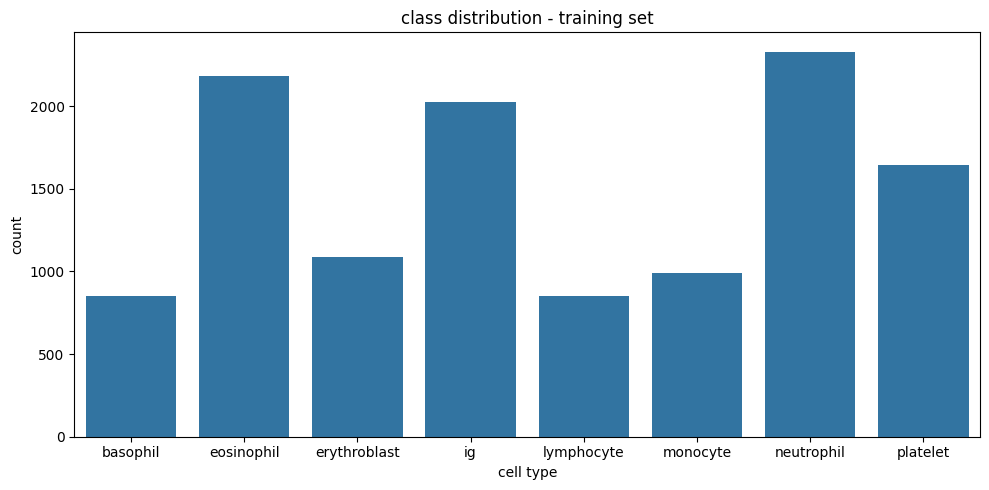

In [2]:
labels = [train_dataset[i][1].item() for i in range(len(train_dataset))]
counts = Counter(labels)

plt.figure(figsize=(10, 5))
sns.barplot(x=cell_types, y=[counts[i] for i in range(8)])
plt.title('class distribution - training set')
plt.ylabel('count')
plt.xlabel('cell type')
plt.tight_layout()
plt.savefig('../figures/class_distribution.png', dpi=150)
plt.show()

# Sample Images per Class

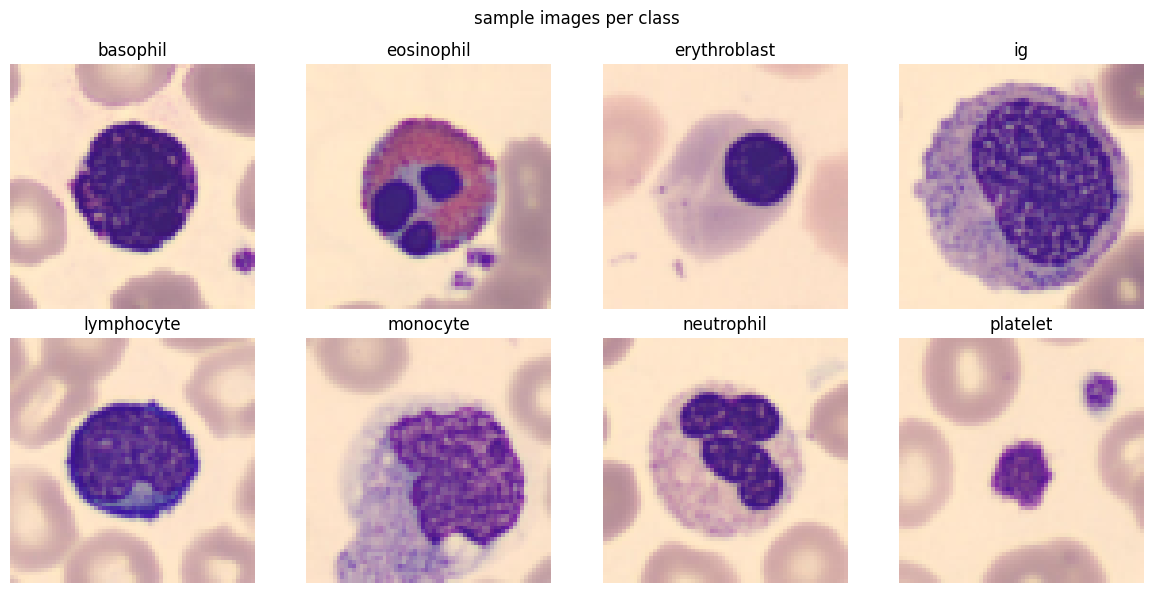

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
shown = {i: False for i in range(8)}

for img, label in train_dataset:
    l = label.item()
    if not shown[l]:
        row, col = l // 4, l % 4
        axes[row, col].imshow(img)
        axes[row, col].set_title(cell_types[l])
        axes[row, col].axis('off')
        shown[l] = True
    if all(shown.values()):
        break

plt.suptitle('sample images per class')
plt.tight_layout()
plt.savefig('../figures/sample_images.png', dpi=150)
plt.show()

# Pixel Intensity Distribution

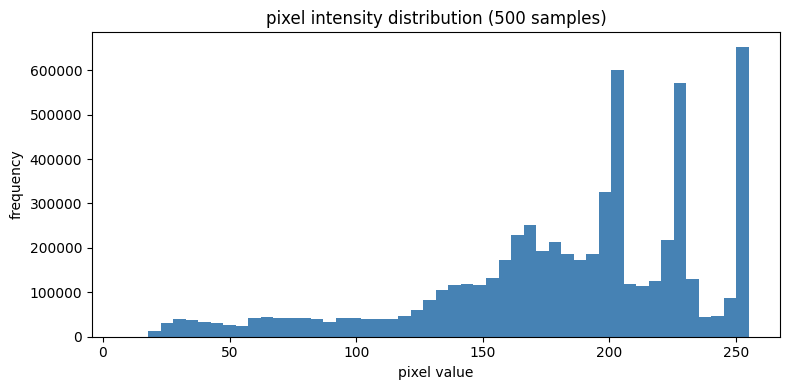

In [4]:
sample_imgs = np.array([np.array(train_dataset[i][0]) for i in range(500)])

plt.figure(figsize=(8, 4))
plt.hist(sample_imgs.flatten(), bins=50, color='steelblue', edgecolor='none')
plt.title('pixel intensity distribution (500 samples)')
plt.xlabel('pixel value')
plt.ylabel('frequency')
plt.tight_layout()
plt.savefig('../figures/pixel_distribution.png', dpi=150)
plt.show()

# Split Summary Table

In [5]:
for split, ds in [('train', train_dataset), ('val', val_dataset), ('test', test_dataset)]:
    labels = [ds[i][1].item() for i in range(len(ds))]
    counts = Counter(labels)
    print(f"\n{split} ({len(ds)} total)")
    for i, name in enumerate(cell_types):
        print(f"  {name:20s}: {counts[i]:4d} ({counts[i]/len(ds)*100:.1f}%)")


train (11959 total)
  basophil            :  852 (7.1%)
  eosinophil          : 2181 (18.2%)
  erythroblast        : 1085 (9.1%)
  ig                  : 2026 (16.9%)
  lymphocyte          :  849 (7.1%)
  monocyte            :  993 (8.3%)
  neutrophil          : 2330 (19.5%)
  platelet            : 1643 (13.7%)

val (1712 total)
  basophil            :  122 (7.1%)
  eosinophil          :  312 (18.2%)
  erythroblast        :  155 (9.1%)
  ig                  :  290 (16.9%)
  lymphocyte          :  122 (7.1%)
  monocyte            :  143 (8.4%)
  neutrophil          :  333 (19.5%)
  platelet            :  235 (13.7%)

test (3421 total)
  basophil            :  244 (7.1%)
  eosinophil          :  624 (18.2%)
  erythroblast        :  311 (9.1%)
  ig                  :  579 (16.9%)
  lymphocyte          :  243 (7.1%)
  monocyte            :  284 (8.3%)
  neutrophil          :  666 (19.5%)
  platelet            :  470 (13.7%)
